In [54]:
from dotenv import load_dotenv
import os
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()

# ---------- LLMs ----------

llm_groq = ChatGroq(
    api_key=os.getenv("GROQ_API_KEY"),
    model="groq/compound",
    temperature=0.1,
)

llm_google = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=os.getenv("GOOGLE_API_KEY"),
)


llm_xiaomi = ChatOpenAI(
    model="xiaomi/mimo-v2-flash:free",
    openai_api_key=os.getenv("OPENROUTER_API_KEY"),
    openai_api_base="https://openrouter.ai/api/v1",
)

llm_gemma = ChatOpenAI(
    model="google/gemma-3-4b-it:free",
    openai_api_key=os.getenv("OPENROUTER_API_KEY"),
    openai_api_base="https://openrouter.ai/api/v1",
)


In [55]:
import subprocess
from contextlib import asynccontextmanager
from langchain_mcp_adapters.client import MultiServerMCPClient
import langchain_mcp_adapters.sessions

# Patch stdio_client to use DEVNULL for stderr to fix Jupyter fileno() error
original_stdio_client = langchain_mcp_adapters.sessions.stdio_client

@asynccontextmanager
async def patched_stdio_client(server_params):
    async with original_stdio_client(server_params, errlog=subprocess.DEVNULL) as res:
        yield res

langchain_mcp_adapters.sessions.stdio_client = patched_stdio_client


In [65]:
from langchain_mcp_adapters.client import MultiServerMCPClient

# client = MultiServerMCPClient(
#     {
#         "railway": {
#             "command": "node",
#             "args": [
#                 "C:/Users/rahul/Desktop/mcp_server/indian-railways-mcp/build/index.js"
#             ],
#             "transport": "stdio",
#         },
#         "google-flights": {
#             "command": "docker",
#             "args": ["run", "-i", "--rm", "mcp/google-flights"],
#             "transport": "stdio"
#         },
#         "openbnb-airbnb": {
#             "command": "docker",
#             "args": [
#                 "run",
#                 "-i",
#                 "--rm",
#                 "mcp/openbnb-airbnb"
#             ],
#             "transport": "stdio"
#         }
#     }
# )

from langchain_mcp_adapters.client import MultiServerMCPClient

client = MultiServerMCPClient({
    "expense-tracker": {
        "transport": "stdio",
        "command": "uv",
        "args": [
            "run",
            "--directory",
            "C:/Users/rahul/Desktop/mcp_server/expense-tracker-mcp-server",
            "main.py"
        ]
    }
}
)
tools = await client.get_tools()


In [66]:
tools

[StructuredTool(name='add_expense', description='Add a new expense to the database.', args_schema={'properties': {'amount': {'type': 'number'}, 'category': {'type': 'string'}, 'subcategory': {'default': '', 'type': 'string'}, 'date': {'default': '', 'type': 'string'}, 'description': {'default': '', 'type': 'string'}}, 'required': ['amount', 'category'], 'type': 'object'}, metadata={'_meta': {'_fastmcp': {'tags': []}}}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x00000184042FE3E0>),
 StructuredTool(name='list_expenses', description='List expenses filtered by category and an optional date range.\n\nIf start_date or end_date are missing, the function will return results across the full DB range.', args_schema={'properties': {'category': {'default': '', 'type': 'string'}, 'start_date': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'default': None}, 'end_date': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'd

In [98]:
for tool in tools:
    print(tool.name)
 

get_flights_on_date
get_round_trip_flights
find_all_flights_in_range


In [99]:
train_tool = None

for t in tools:
    if t.name == "get_flights_on_date":
        train_tool = t

In [100]:
train_tool

StructuredTool(name='get_flights_on_date', description='\n    Fetches available one-way flights for a specific date between two airports.\n    Can optionally return only the cheapest flight found.\n\n    Args:\n        origin: Origin airport code (e.g., "DEN").\n        destination: Destination airport code (e.g., "LAX").\n        date: The specific date to search (YYYY-MM-DD format).\n        adults: Number of adult passengers (default: 1).\n        seat_type: Fare class (e.g., "economy", "business", default: "economy").\n        return_cheapest_only: If True, returns only the cheapest flight (default: False).\n\n    Example Args:\n        {"origin": "SFO", "destination": "JFK", "date": "2025-07-20"}\n        {"origin": "SFO", "destination": "JFK", "date": "2025-07-20", "return_cheapest_only": true}\n    ', args_schema={'properties': {'origin': {'title': 'Origin', 'type': 'string'}, 'destination': {'title': 'Destination', 'type': 'string'}, 'date': {'title': 'Date', 'type': 'string'},

In [102]:
result = await train_tool.ainvoke({
    "origin": "DEN",
    "destination": "LAX",
    "date":"2026-03-07"
})

print(result)

[{'type': 'text', 'text': '{\n  "search_parameters": {\n    "origin": "DEN",\n    "destination": "LAX",\n    "date": "2026-03-07",\n    "adults": 1,\n    "seat_type": "economy",\n    "return_cheapest_only": false\n  },\n  "flights": [\n    {\n      "is_best": true,\n      "name": "Frontier",\n      "departure": "6:11 AM on Sat, Mar 7",\n      "arrival": "9:59 AM on Sat, Mar 7",\n      "arrival_time_ahead": "",\n      "duration": "4 hr 48 min",\n      "stops": 1,\n      "delay": null,\n      "price": "\\u20b915576"\n    },\n    {\n      "is_best": true,\n      "name": "Frontier",\n      "departure": "9:00 AM on Sat, Mar 7",\n      "arrival": "10:49 AM on Sat, Mar 7",\n      "arrival_time_ahead": "",\n      "duration": "2 hr 49 min",\n      "stops": 0,\n      "delay": null,\n      "price": "\\u20b923823"\n    },\n    {\n      "is_best": true,\n      "name": "Frontier",\n      "departure": "10:29 PM on Sat, Mar 7",\n      "arrival": "12:16 AM on Sun, Mar 8",\n      "arrival_time_ahead": "

In [36]:
result[0]['text']

'Trains between stations GODA and NDLS: {"success":true,"time_stamp":1772705258594,"data":[{"trainBase":{"trainNumber":"12349","trainName":"GODA NDLS HMSFR","sourceStationName":"Godda","sourceStationCode":"GODA","destinationStationName":"New Delhi","destinationStationCode":"NDLS","fromStationName":"Godda","fromStationCode":"GODA","toStationName":"New Delhi","toStationCode":"NDLS","departureTime":"14.05","arrivalTime":"12.50","travelDuration":"22.45","operatingDays":"1000000"}},{"trainBase":{"trainNumber":"14049","trainName":"GODA DLI EXPRESS","sourceStationName":"Godda","sourceStationCode":"GODA","destinationStationName":"Delhi","destinationStationCode":"DLI","fromStationName":"Godda","fromStationCode":"GODA","toStationName":"Delhi","toStationCode":"DLI","departureTime":"10.05","arrivalTime":"09.10","travelDuration":"23.05","operatingDays":"0010000"}},{"trainBase":{"trainNumber":"19604","trainName":"GODA  DOZ EXP","sourceStationName":"Godda","sourceStationCode":"GODA","destinationStati

In [39]:
res=llm_groq.invoke("""Trains between stations GODA and NDLS: {"success":true,"time_stamp":1772705258594,"data":[{"trainBase":{"trainNumber":"12349","trainName":"GODA NDLS HMSFR","sourceStationName":"Godda","sourceStationCode":"GODA","destinationStationName":"New Delhi","destinationStationCode":"NDLS","fromStationName":"Godda","fromStationCode":"GODA","toStationName":"New Delhi","toStationCode":"NDLS","departureTime":"14.05","arrivalTime":"12.50","travelDuration":"22.45","operatingDays":"1000000"}},{"trainBase":{"trainNumber":"14049","trainName":"GODA DLI EXPRESS","sourceStationName":"Godda","sourceStationCode":"GODA","destinationStationName":"Delhi","destinationStationCode":"DLI","fromStationName":"Godda","fromStationCode":"GODA","toStationName":"Delhi","toStationCode":"DLI","departureTime":"10.05","arrivalTime":"09.10","travelDuration":"23.05","operatingDays":"0010000"}},{"trainBase":{"trainNumber":"19604","trainName":"GODA  DOZ EXP","sourceStationName":"Godda","sourceStationCode":"GODA","destinationStationName":"Daurai (Ajmer)","destinationStationCode":"DOZ","fromStationName":"Godda","fromStationCode":"GODA","toStationName":"Delhi","toStationCode":"DLI","departureTime":"05.00","arrivalTime":"08.15","travelDuration":"27.15","operatingDays":"0100000"}}]} summarize this text in proper manner""")
print(res)

content='**Summary of Trains from\u202fGODA\u202f(Godda) to\u202fNDLS\u202f(New\u202fDelhi)**  \n\nThe JSON payload contains three train entries that originate at Godda (code\u202fGODA). Only one of them terminates at New\u202fDelhi (code\u202fNDLS); the other two end at Delhi (code\u202fDLI), which is effectively the same city for passenger purposes.\n\n| # | Train No. | Train Name | Destination (Code) | Dep.\u202fTime (GODA) | Arr.\u202fTime (Destination) | Travel\u202fDuration | Operating\u202fDays* |\n|---|-----------|------------|--------------------|------------------|--------------------------|-----------------|-----------------|\n| 1 | **12349** | GODA\u202fNDLS\u202fHMSFR | New\u202fDelhi (NDLS) | **14:05** | **12:50** (next day) | **22\u202fh\u202f45\u202fm** | Mon |\n| 2 | **14049** | GODA\u202fDLI\u202fEXPRESS | Delhi (DLI) | **10:05** | **09:10** (next day) | **23\u202fh\u202f05\u202fm** | Thu |\n| 3 | **19604** | GODA\u202fDOZ\u202fEXP | Delhi (DLI) | **05:00** | **08:15*

In [81]:
import numpy as np

np.random.seed(42)
print(np.random.rand(3))

[0.37454012 0.95071431 0.73199394]


In [ ]:
np.random.seed(1001)
print(np.random.rand(3))

[0.30623218 0.26506357 0.19606006]


: 

In [74]:
res.content

NameError: name 'res' is not defined

In [41]:
from langchain_community.tools import YouTubeSearchTool

In [42]:
tool=YouTubeSearchTool()

In [43]:
tool.run("lex fridman")

"['https://www.youtube.com/watch?v=Mde2q7GFCrw&pp=ygULbGV4IGZyaWRtYW4%3D', 'https://www.youtube.com/watch?v=EV7WhVT270Q&pp=ygULbGV4IGZyaWRtYW4%3D']"

In [50]:
tools

[StructuredTool(name='get-station-live-status', description='Get live station status', args_schema={'type': 'object', 'properties': {'stationCode': {'type': 'string', 'description': 'The station code to get live status for'}}, 'required': ['stationCode'], 'additionalProperties': False, '$schema': 'http://json-schema.org/draft-07/schema#'}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x000002376038A840>),
 StructuredTool(name='get-train-details', description='Get train details by train number', args_schema={'type': 'object', 'properties': {'trainNumber': {'type': 'string', 'description': 'The train number to get details for'}}, 'required': ['trainNumber'], 'additionalProperties': False, '$schema': 'http://json-schema.org/draft-07/schema#'}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x000002376038BF60>),
 StructuredTool(name='get-trains-betwe

In [2]:
from langgraph.graph import StateGraph,START,END
from bot1_LG_MCP.resources.llms import bot3_llm
import asyncio
from langgraph.prebuilt import ToolNode,tools_condition
from bot1_LG_MCP.resources.tools import get_all_tools
from typing import TypedDict,Annotated,Dict,List
from langchain_core.messages import BaseMessage,AIMessage,HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import add_messages


llm_google=bot3_llm()

tools=await get_all_tools()
llm_with_tools=llm_google.bind_tools(tools)

class chatstate(TypedDict):
    message:Annotated[List[BaseMessage],add_messages]

    

Error: fileno


In [3]:
def llm_node(state:chatstate):
    messages=state["messages"]
    system_messgae={
        "role":"system",
        "content":"You are a helpful assistant and use the same language as input lanmguage for answer and use tools if needed"
    }
    response=llm_with_tools.invoke([system_messgae]+messages)
    return {"messages":[response]}

In [57]:
tools

[StructuredTool(name='get-station-live-status', description='Get live station status', args_schema={'type': 'object', 'properties': {'stationCode': {'type': 'string', 'description': 'The station code to get live status for'}}, 'required': ['stationCode'], 'additionalProperties': False, '$schema': 'http://json-schema.org/draft-07/schema#'}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x000002376038A840>),
 StructuredTool(name='get-train-details', description='Get train details by train number', args_schema={'type': 'object', 'properties': {'trainNumber': {'type': 'string', 'description': 'The train number to get details for'}}, 'required': ['trainNumber'], 'additionalProperties': False, '$schema': 'http://json-schema.org/draft-07/schema#'}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x000002376038BF60>),
 StructuredTool(name='get-trains-betwe

In [4]:
graph=StateGraph(chatstate)
graph.add_node("llm_node",llm_node)
graph.add_node("tools", ToolNode(tools))
graph.add_edge(START,"llm_node")
graph.add_conditional_edges("llm_node",tools_condition)
graph.add_edge("tools","llm_node")

    
config={
    "configurable":{
        "thread_id":1
    }
}
check_point=InMemorySaver()
graph=graph.compile(checkpointer=check_point)

In [21]:
from typing_extensions import TypedDict
from typing import Annotated, Sequence, Dict, Any, List
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.postgres.aio import AsyncPostgresSaver
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage, ToolMessage
import operator
from bot1_LG_MCP.resources.tools import internet_search
from bot1_LG_MCP.resources.llms import bot4_llm
from bot2_exp_tracker.main import create_graph2
from bot3_rag.rag_engine import build_graph
from bot1_LG_MCP.main import create_graph
import json
from langgraph.checkpoint.memory import InMemorySaver

class SupervisorState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    next_node: str                      # "bot1", "bot2", "bot3", "llm", "END"
    bot_outputs: Dict[str, Any]         # {"bot1": {...}, "bot2": {...}}
    goal_achieved: bool                 # Loop control

class MultiBotAgent:
    def __init__(self):
        self.bot1_graph =  create_graph(checkpointer=InMemorySaver())     # Your subgraphs
        self.bot2_graph =  create_graph2()
        self.bot3_graph = build_graph()
        self.checkpointer = None

    async def create_supervisor_graph(self) -> StateGraph:
        """✅ FIXED: Production supervisor with looping + multi-node."""
        tools = [internet_search]
        supervisor_llm = bot4_llm().bind_tools(tools)

        # ✅ FIXED: Pass config to subgraphs
        async def call_bot1(state: SupervisorState) -> Dict[str, Any]:
            config = {"configurable": {"thread_id": state.get("thread_id", "default")}}
            result = await self.bot1_graph.ainvoke(
                {"messages": state["messages"]},
                config
            )
            return {
                "bot_outputs": {**state.get("bot_outputs", {}), "bot1": result},
                "messages": [AIMessage(content=f"Bot1: {result['messages'][-1].content}")]
            }

        async def call_bot2(state: SupervisorState) -> Dict[str, Any]:
            config = {"configurable": {"thread_id": state.get("thread_id", "default")}}
            result = await self.bot2_graph.ainvoke(
                {"messages": state["messages"]},
                config
            )
            return {
                "bot_outputs": {**state.get("bot_outputs", {}), "bot2": result},
                "messages": [AIMessage(content=f"Bot2: {result['messages'][-1].content}")]
            }

        async def call_bot3(state: SupervisorState) -> Dict[str, Any]:
            config = {"configurable": {"thread_id": state.get("thread_id", "default")}}
            result = await self.bot3_graph.ainvoke(
                {"messages": state["messages"]},
                config
            )
            return {
                "bot_outputs": {**state.get("bot_outputs", {}), "bot3": result},
                "messages": [AIMessage(content=f"Bot3: {result['messages'][-1].content}")]
            }

        async def supervisor_decider(state: SupervisorState) -> Dict[str, Any]:
            """✅ LLM decides: which bot(s)? Loop? End?"""
            recent_msgs = state["messages"][-5:]
            system_prompt = """You route queries to specialized bots:
            - bot1: Travel booking
            - bot2: Expense tracking  
            - bot3: Document RAG
            - Use multiple if needed
            - Say 'END' when goal achieved
            
            Respond ONLY with JSON: {"next": "bot1|bot2|bot3|llm|END", "reason": "..."}
            """
            
            response = await supervisor_llm.invoke([system_prompt] + recent_msgs[-4:])
            
            # Parse LLM decision
            decision = {"next": "llm", "reason": "Default"}
            try:
                decision = json.loads(response.content)
            except:
                pass
            
            return {
                "next_node": decision["next"],
                "messages": [AIMessage(content=f"Decision: {decision['reason']}")]
            }

        # ✅ Main LLM for final answer
        async def final_llm(state: SupervisorState) -> Dict[str, Any]:
            recent = state["messages"][-10:]
            system = "Summarize all bot outputs and give final answer."
            response = await bot4_llm().ainvoke([system] + recent)
            return {"messages": [response], "goal_achieved": True}

        builder = StateGraph(SupervisorState)
        builder.add_node("decider", supervisor_decider)
        builder.add_node("bot1", call_bot1)
        builder.add_node("bot2", call_bot2) 
        builder.add_node("bot3", call_bot3)
        builder.add_node("llm", final_llm)

        # ✅ Conditional routing
        def route_to_node(state: SupervisorState) -> str:
            next_node = state.get("next_node", "decider")
            if next_node == "END":
                return END
            return next_node

        builder.add_edge(START, "decider")
        builder.add_conditional_edges("decider", route_to_node)
        builder.add_conditional_edges("bot1", route_to_node)
        builder.add_conditional_edges("bot2", route_to_node)
        builder.add_conditional_edges("bot3", route_to_node)
        builder.add_edge("llm", END)
        cp=InMemorySaver()
        graph= builder.compile(checkpointer=cp)
        return graph

In [22]:
agent = MultiBotAgent()
supervisor_graph = await agent.create_supervisor_graph()

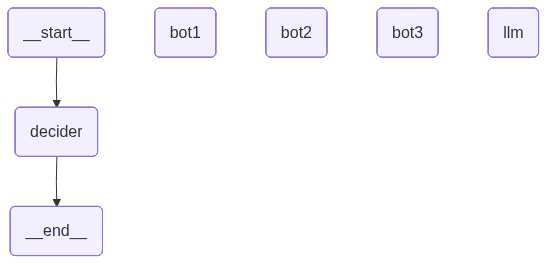

In [23]:
supervisor_graph

In [73]:
res = graph.invoke(
                    {"messages": [HumanMessage(content="whats the weather of indore")]},
                    config={"configurable": {"thread_id": "1"}}
                )


print(res)

KeyError: 'messages'

In [9]:
import cv2

In [13]:
image = cv2.imread("photo-1531129630896-1744cab0cafd.avif")

cv2.imshow("image showing",image)
cv2.waitKey(0)
cv2.destroyAllWindows()

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:973: error: (-215:Assertion failed) size.width>0 && size.height>0 in function 'cv::imshow'


In [14]:
import cv2

image = cv2.imread("photo-1531129630896-1744cab0cafd.avif")

print(type(image))

if image is None:
    print("Image not loaded. Check path or format.")
else:
    cv2.imshow("image showing", image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

<class 'NoneType'>
Image not loaded. Check path or format.


In [11]:
if image is not None:
    cv2.imshow("image showing",image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
else:
    print("no image loaded")

no image loaded


In [2]:
import json
import logging
import time
from pathlib import Path

from docling.datamodel.accelerator_options import AcceleratorDevice, AcceleratorOptions
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import (
    PdfPipelineOptions,
    TableStructureOptions,
)
from docling.document_converter import DocumentConverter, PdfFormatOption

c:\Users\rahul\Desktop\vscode_files\project1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
pipeline_options = PdfPipelineOptions()
pipeline_options.do_ocr = True
pipeline_options.do_table_structure = True
pipeline_options.generate_picture_images=True
pipeline_options.table_structure_options = TableStructureOptions(
    do_cell_matching=True
)
pipeline_options.ocr_options.lang = ["es"]
pipeline_options.accelerator_options = AcceleratorOptions(
    num_threads=4, device=AcceleratorDevice.AUTO
)

doc_converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

In [13]:
output_dir = Path("scratch")
output_dir.mkdir(parents=True, exist_ok=True)
doc_filename = conv_result.input.file.stem

In [21]:
with (output_dir/f"{doc_filename}.txt").open("w", encoding="utf-8") as fp:
        fp.write(conv_result.document.export_to_markdown(image_mode="embedded",strict_text=True))

Parameter `strict_text` has been deprecated and will be ignored.


In [4]:
conv_result = doc_converter.convert(pdf_path)
doc = conv_result.document

[INFO] 2026-03-17 13:59:35,013 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-03-17 13:59:35,050 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\rahul\Desktop\vscode_files\project1\.venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-03-17 13:59:35,053 [RapidOCR] main.py:53: Using C:\Users\rahul\Desktop\vscode_files\project1\.venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-03-17 13:59:35,233 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-03-17 13:59:35,239 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\rahul\Desktop\vscode_files\project1\.venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2026-03-17 13:59:35,239 [RapidOCR] main.py:53: Using C:\Users\rahul\Desktop\vscode_files\project1\.venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2026-03-17 13:59:35,332 [RapidOCR] base.py:22: Using engine

In [5]:
def get_page(item):
    if hasattr(item, "prov") and item.prov:
        return item.prov[0].page_no   # ✅ correct field
    return None

In [6]:
chunks = []

for item, level in doc.iterate_items():

    label = str(item.label)

    # ---------------- TEXT ----------------
    if label in ["text", "paragraph", "section_header", "title"]:
        text = getattr(item, "text", "").strip()

        if text:
            chunks.append({
                "type": "text",
                "content": text,
                "page": get_page(item)
            })

    # ---------------- TABLE ----------------
    elif label == "table":
        try:
            table_md = item.export_to_markdown(doc)
        except:
            table_md = ""

        chunks.append({
            "type": "table",
            "content": table_md,
            "page": get_page(item)
        })

    # ---------------- IMAGE ----------------
    elif label == "picture":

        # get image
        image = item.get_image(doc)

        # get caption
        caption = ""
        try:
            caption = item.caption_text(doc)
        except:
            pass

        chunks.append({
            "type": "image",
            "content": caption,
            "image": image,   # PIL image
            "page": get_page(item)
        })

In [11]:
chunks

[{'type': 'text',
  'content': 'AM050F MBB PV Cell Soldering Stringer Maintenance Manual',
  'page': 1},
 {'type': 'image',
  'content': '',
  'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=363x189>,
  'page': 1},
 {'type': 'image',
  'content': '',
  'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=194x65>,
  'page': 1},
 {'type': 'text',
  'content': 'Wuxi\xa0Autowell\xa0Technology\xa0Co.,\xa0Ltd.',
  'page': 1},
 {'type': 'text', 'content': '1.2 Basics\xa0of\xa0Maintenance', 'page': 6},
 {'type': 'text', 'content': 'WD40', 'page': 6},
 {'type': 'text',
  'content': 'Cleaning\xa0object:\xa0WD40\xa0is\xa0used\xa0to\xa0clean\xa0the\xa0flux\xa0crystals\xa0on\xa0the\xa0surface\xa0of\xa0metal\xa0parts\xa0(solder\xa0station, flux\xa0nozzle\xa0and\xa0bracket,\xa0guide\xa0plate,\xa0Axis\xa0Z\xa0(J3),\xa0metal\xa0part\xa0of\xa0traction\xa0device,\xa0ribbon\xa0holder,\xa0slide\xa0bar for\xa0tension\xa0wheel).',
  'page': 6},
 {'type': 'text', 'content': 'Specificati

In [20]:
img=chunks[143]['image']

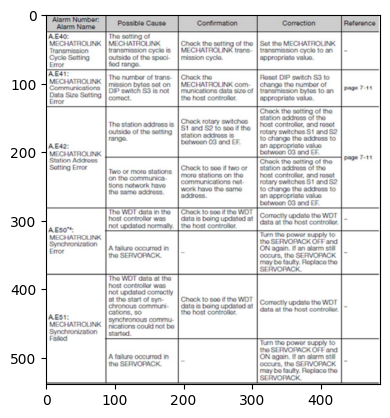

In [21]:
import matplotlib.pyplot as plt

plt.imshow(img)

In [34]:
import os
from pageindex import PageIndexClient
from dotenv import load_dotenv
load_dotenv()

True

In [35]:
import os

print(os.getenv("PAGEINDEX_API_KEY"))  # should NOT be None

66fe5b760d574bb1aa6773c865697491


In [36]:
PAGEINDEX_API_KEY=os.getenv("PAGEINDEX_API_KEY")

In [38]:
pdf_path=r"C:\Users\rahul\Desktop\vscode_files\project1\data\ATW-TS-037 AM050K多主栅光伏划焊联体串焊机维护保养手册-EN-V1.1.pdf"